In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
# plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
with open('setting1_plot_df.pkl', 'rb') as file:
    df1 = pkl.load(file)
df1.head()

,eval_type,algorithm,num_shots,responses_to_include,debug,total_score,win_rate_against_bestresponse,win_rate_against_gpt4o,time_taken,seed,...,mean_test_oasst_pythia_7b,mean_train_oasst_pythia_7b,std_train_oasst_pythia_7b,datetime,vllm_gpu_utilization_pct,vllm_model_name,user_embedding_type,user_embedding_computed_from_n_pr,n_similar_users_to_retrieve,meta_learning_dataset
0,pairwise_pref,ZeroShotAlgorithm,0,none,False,-1.050789,3.9,8.0,1132.483011,27,...,-0.818068,4.706351,1.365914,2024-08-15 10:14:16,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k
1,pairwise_pref,KShotICLAlgorithm,1,winning_only,False,-0.517598,9.6,17.7,1788.965076,27,...,-0.701205,4.706351,1.365914,2024-08-15 11:53:12,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k
2,pairwise_pref,KShotICLAlgorithm,1,winning_and_losing,False,-0.514149,11.0,17.8,1827.829406,27,...,-0.614845,4.706351,1.365914,2024-08-15 12:23:55,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k
3,pairwise_pref,KShotICLAlgorithm,5,winning_only,False,-0.172885,15.0,24.4,2974.103092,27,...,-0.123991,4.706351,1.365914,2024-08-15 15:57:01,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k
4,pairwise_pref,KShotICLAlgorithm,5,winning_and_losing,False,-0.292088,13.9,22.0,3101.477600,27,...,-0.237743,4.706351,1.365914,2024-08-15 16:49:00,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k


In [3]:
with open('setting2_plot_df.pkl', 'rb') as file:
    df2 = pkl.load(file)
df2.head()

,eval_type,algorithm,num_shots,responses_to_include,debug,total_score,win_rate_against_bestresponse,win_rate_against_gpt4o,time_taken,seed,...,mean_test_oasst_pythia_7b,mean_train_oasst_pythia_7b,std_train_oasst_pythia_7b,datetime,vllm_gpu_utilization_pct,vllm_model_name,user_embedding_type,user_embedding_computed_from_n_pr,n_similar_users_to_retrieve,meta_learning_dataset
25,pairwise_pref,MetaLearnKShotICLAlgorithm,3,winning_only,False,-0.401976,11.0,18.9,1714.959510,27,...,-0.319743,4.706351,1.365914,2024-08-15 21:54:20,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,5.0,5.0,andrewsiah/MetaLearningPairwisePrefDB_Argmax_1000
39,pairwise_pref,MetaLearnKShotICLAlgorithm,3,winning_only,False,-0.371147,10.3,18.5,1389.894474,27,...,-0.315396,4.706351,1.365914,2024-08-16 01:47:59,0.5,meta-llama/Meta-Llama-3-8B-Instruct,losing,5.0,5.0,andrewsiah/MetaLearningPairwisePrefDB_Argmax_1000
53,pairwise_pref,MetaLearnKShotICLAlgorithm,3,winning_only,False,-0.318578,13.1,21.9,1521.549679,27,...,-0.244343,4.706351,1.365914,2024-08-16 05:56:24,0.5,meta-llama/Meta-Llama-3-8B-Instruct,win_minus_lose,5.0,5.0,andrewsiah/MetaLearningPairwisePrefDB_Argmax_1000
7,pairwise_pref,SelfKShotICLAlgorithm,3,winning_only,False,-0.346193,12.6,20.4,1266.523925,27,...,-0.219962,4.706351,1.365914,2024-08-15 12:06:20,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k
0,pairwise_pref,ZeroShotAlgorithm,0,none,False,-1.050789,3.9,8.0,1122.829170,27,...,-0.818068,4.706351,1.365914,2024-08-15 09:53:34,0.5,meta-llama/Meta-Llama-3-8B-Instruct,winning,10.0,10.0,andrewsiah/MetaLearningPrefDs1k


In [4]:
set(df2["user_embedding_type"].tolist())

{'losing', 'win_minus_lose', 'winning'}

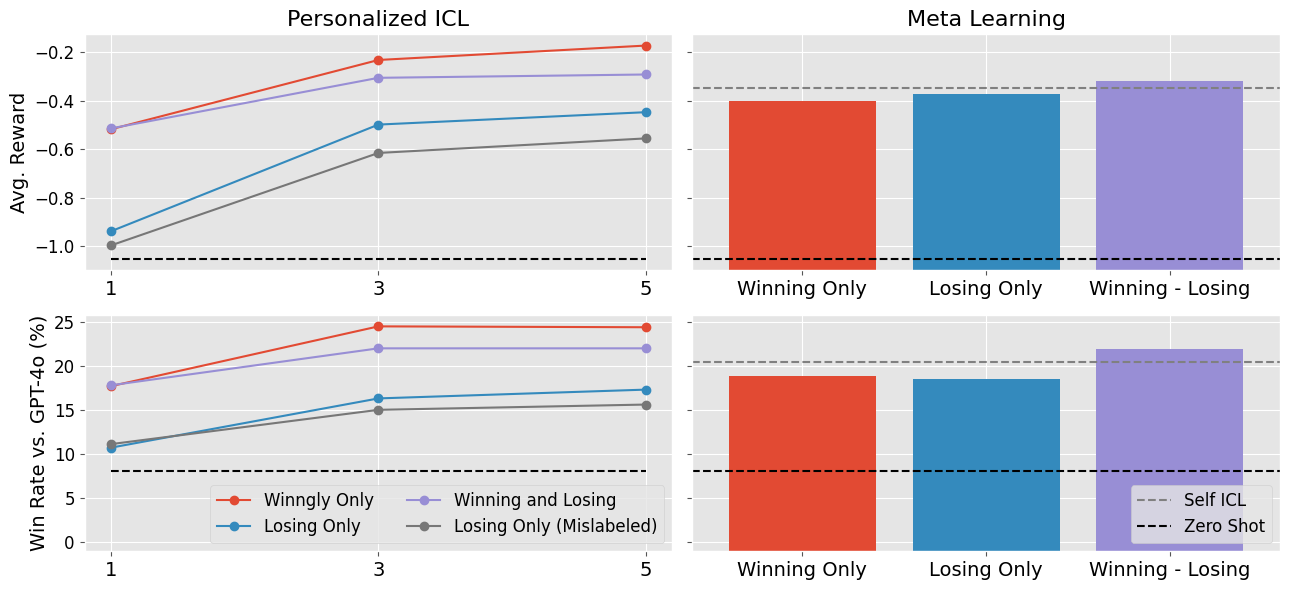

In [14]:
s1_mtds = [
    'winning_only',
    'losing_only',
    'winning_and_losing',
    'losing_as_winning_only',
]
s1_map = {
    'losing_as_winning_only': "Losing Only (Mislabeled)",
    'losing_only': "Losing Only",
    'winning_and_losing': "Winning and Losing",
    'winning_only': "Winngly Only"
}

s2_mtds = [ 'winning', 'losing', 'win_minus_lose']
s2_map = {
    'losing': "Losing Only",
    'winning': "Winning Only",
    'win_minus_lose': "Winning - Losing",
}


plt.rcParams["figure.figsize"] = (13,6)
fig, axs = plt.subplots(2,2,sharey="row")

scores = ["total_score", "win_rate_against_gpt4o"]

for sidx, score in enumerate(scores):

    for mtd in s1_mtds:

        sub_df = df1[(df1["responses_to_include"] == mtd)][["num_shots", score]].sort_values(["num_shots"])

        x = sub_df["num_shots"]
        y = sub_df[score]

        axs[sidx, 0].plot(x, y, "-o", label=s1_map[mtd])

    offset=1.1
    for mtd in s2_mtds:

        sub_df = df2[(df2["user_embedding_type"] == mtd) & (df2["algorithm"] == "MetaLearnKShotICLAlgorithm")][["num_shots", score]].sort_values(["num_shots"])

        y = sub_df[score].tolist()[0]
        axs[sidx, 1].bar(s2_map[mtd], y+offset, bottom=-offset)

    self_icl = df2[df2["algorithm"] == "SelfKShotICLAlgorithm"][score].tolist()[0]
    axs[sidx, 1].plot([-0.6, 2.6], [self_icl, self_icl], "--", color="grey", label="Self ICL")

    zeroshot = df1[df1["num_shots"]==0][score].tolist()[0]
    axs[sidx, 0].plot([1,5], [zeroshot, zeroshot], "--", color="k")
    axs[sidx, 1].plot([-0.6, 2.6], [zeroshot, zeroshot], "--", color="k", label="Zero Shot")



for i in range(2):
    axs[i,0].set_xticks([1,3,5], [1,3,5], size=14, color="k")
    axs[i,1].set_xlim(-0.6, 2.6)
    axs[i,1].set_xticks([0.0, 1.0, 2.0], [s2_map[m] for m in s2_mtds], size=14, color="k")

# axs[1,0].set_xticks([1,3,5], [1,3,5], size=14)
axs[0,0].set_ylabel("Avg. Reward", size=14, color="k")
axs[1,0].set_ylabel("Win Rate vs. GPT-4o (%)", size=14, color="k")
axs[0,0].set_title("Personalized ICL", size=16, color="k")
axs[0,1].set_title("Meta Learning", size=16, color="k")

# axs[0,1].set_xlim(-0.6, 2.6)
# axs[1,1].set_xlim(-0.6, 2.6)

for i in range(2):
    for j in range(2):
        axs[i,j].tick_params("y", labelcolor="k", labelsize=12)
        axs[i,j].tick_params("x", labelcolor="k")

# axs[0,1].text(-0.2,-0.3,"Self ICL", color="grey", size=14)


axs[1,0].legend(loc="lower right", fontsize=12, ncol=2)
axs[1,1].legend(loc="lower right", fontsize=12)

fig.tight_layout()

plt.savefig("../plots/final_exps.png", dpi=300, bbox_inches="tight")
plt.show()

    